https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df = pd.read_csv('vehicles.csv')
df_original = df.copy()

In [194]:
df = df_original
print(df.shape)
print(df.columns)
df.head()

(426880, 26)
Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='str')


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [195]:
# Show missing percentages
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct.sort_values()

for col, pct in missing_pct.items():
    print(f"{col}: {pct:.2f}%")

id: 0.00%
url: 0.00%
region: 0.00%
region_url: 0.00%
price: 0.00%
state: 0.00%
image_url: 0.02%
posting_date: 0.02%
description: 0.02%
year: 0.28%
transmission: 0.60%
fuel: 0.71%
odometer: 1.03%
model: 1.24%
lat: 1.53%
long: 1.53%
title_status: 1.93%
manufacturer: 4.13%
type: 21.75%
paint_color: 30.50%
drive: 30.59%
VIN: 37.73%
condition: 40.79%
cylinders: 41.62%
size: 71.77%
county: 100.00%


In [196]:
## Feature selection
# If there is more than 50% of rows with nulls, drop
cols_to_drop = [col for col, pct in missing_pct.items() if pct > 50]
print("Dropped:", cols_to_drop) # size and county are dropped
before = df.isnull().sum().sum()
df = df.drop(columns=cols_to_drop)
after = df.isnull().sum().sum()
print(f"Nulls before: {before}\nNulls after: {after}")

# Useless cols to be described in essay
cols_to_drop = ['id', 'url', 'region_url', 'image_url', 'VIN',
                'description', 'lat', 'long', 'posting_date']
df = df.drop(columns=cols_to_drop)

Dropped: ['size', 'county']
Nulls before: 1655336
Nulls after: 922095


In [197]:
print(df.shape)
print(df['region'].nunique())
print(df['state'].nunique())
print(df.select_dtypes(include=['number']).columns)

(426880, 15)
404
51
Index(['price', 'year', 'odometer'], dtype='str')


In [198]:
print(df['price'].describe())
print(df['odometer'].describe())

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64
count    4.224800e+05
mean     9.804333e+04
std      2.138815e+05
min      0.000000e+00
25%      3.770400e+04
50%      8.554800e+04
75%      1.335425e+05
max      1.000000e+07
Name: odometer, dtype: float64


In [199]:
print((df['year'] <= 1950).sum())
print((df['price'] <= 0).sum())

1319
32895


In [200]:
## Outlier removal
# get rid of rows where year is not plausible
df = df[(df['year'] >= 1900) & (df['year'] <= 2026)]

# drop zero price/odometer, probable incomplete listings
df = df[(df['price'] > 0) & (df['odometer'] > 0)]

def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

before = len(df)
df = remove_outliers_iqr(df, 'price')
df = remove_outliers_iqr(df, 'odometer')
after = len(df)
print(f"Rows before: {before}\nRows after: {after}\nDropped: {before - after}")
print(df[['price', 'odometer', 'year']].describe())

Rows before: 389482
Rows after: 378271
Dropped: 11211
               price       odometer           year
count  378271.000000  378271.000000  378271.000000
mean    17827.806721   92315.595681    2011.046943
std     12792.445565   60794.513854       9.384079
min         1.000000       1.000000    1900.000000
25%      7000.000000   39649.000000    2008.000000
50%     14995.000000   88200.000000    2013.000000
75%     26990.000000  135000.000000    2017.000000
max     58448.000000  282000.000000    2022.000000


In [201]:
print(df.isnull().sum().sort_values())

region               0
price                0
year                 0
odometer             0
state                0
transmission      1444
fuel              2059
model             4119
title_status      6778
manufacturer     13311
type             81812
paint_color     111850
drive           115784
condition       142910
cylinders       153659
dtype: int64


In [202]:
## Appropriate handling of nulls
# >20% nulls filled in with unknown
high_null_cols = ['condition', 'cylinders', 'drive', 'type', 'paint_color']
df[high_null_cols] = df[high_null_cols].fillna('unknown')

# <5% nulls filled with mode
low_null_cols = ['fuel', 'title_status', 'manufacturer', 'model', 'transmission']
for col in low_null_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

region          0
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
state           0
dtype: int64

In [203]:
## Feature Transformation
# change condition into a scale from 0-6 based on quality
condition_map = {
    'unknown': 0,
    'salvage': 1,
    'fair': 2,
    'good': 3,
    'excellent': 4,
    'like new': 5,
    'new': 6
}

df['condition'] = df['condition'].map(condition_map)
print(df['condition'].value_counts(dropna=False))

# create an is_automatic for transmission
df['is_automatic'] = (df['transmission'] == 'automatic').astype(int)
df = df.drop(columns=['transmission'])

condition
0    142910
3    116954
4     91301
5     19353
2      6223
6       982
1       548
Name: count, dtype: int64


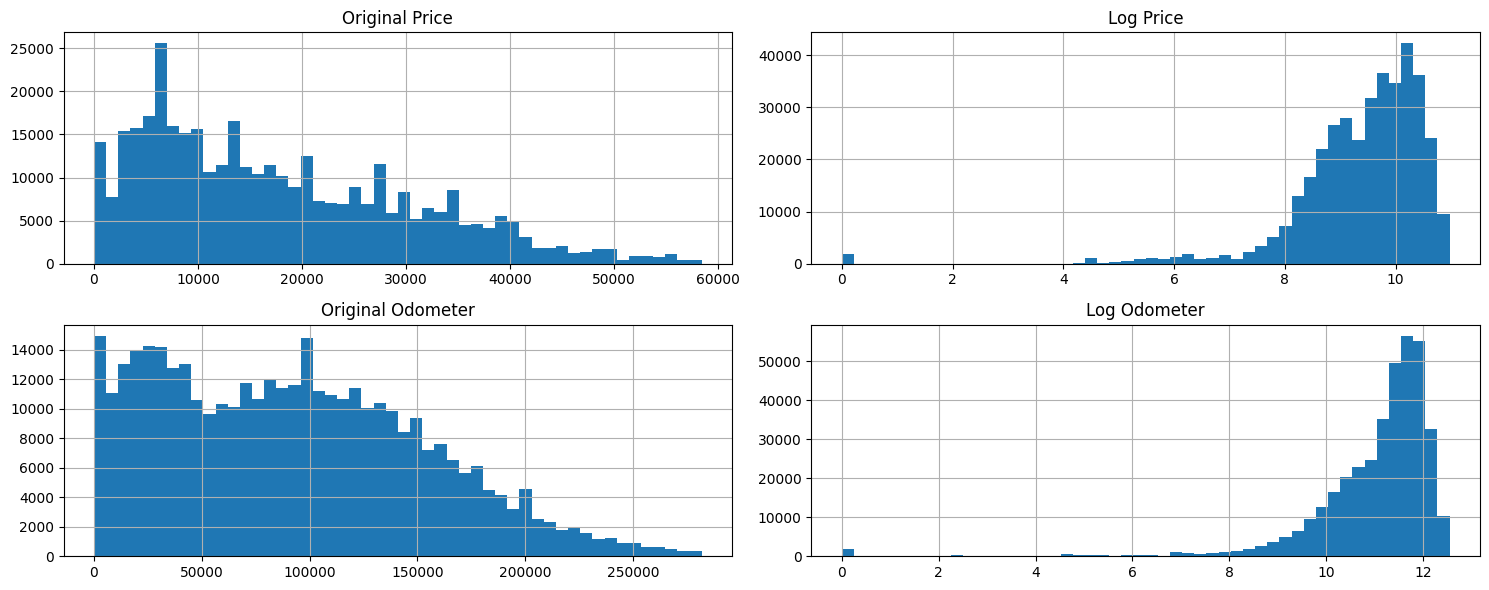

In [204]:
fig, ax = plt.subplots(2, 2, figsize=(15, 6))
df['price'].hist(bins=50, ax=ax[0, 0])
ax[0, 0].set_title('Original Price')
np.log(df['price']).hist(bins=50, ax=ax[0, 1])
ax[0, 1].set_title('Log Price')
df['odometer'].hist(bins=50, ax=ax[1, 0])
ax[1, 0].set_title('Original Odometer')
np.log(df['odometer']).hist(bins=50, ax=ax[1, 1])
ax[1, 1].set_title('Log Odometer')

plt.tight_layout()
plt.show()

In [205]:
# create new price
df['price_log'] = np.log(df['price'])
df['odometer_log'] = np.log(df['odometer'])

# z-score for price
scaler = StandardScaler()
df['price_normalized'] = scaler.fit_transform(df[['price_log']])

# min-max for odometer
minmax = MinMaxScaler()
df['odometer_normalized'] = minmax.fit_transform(df[['odometer_log']])

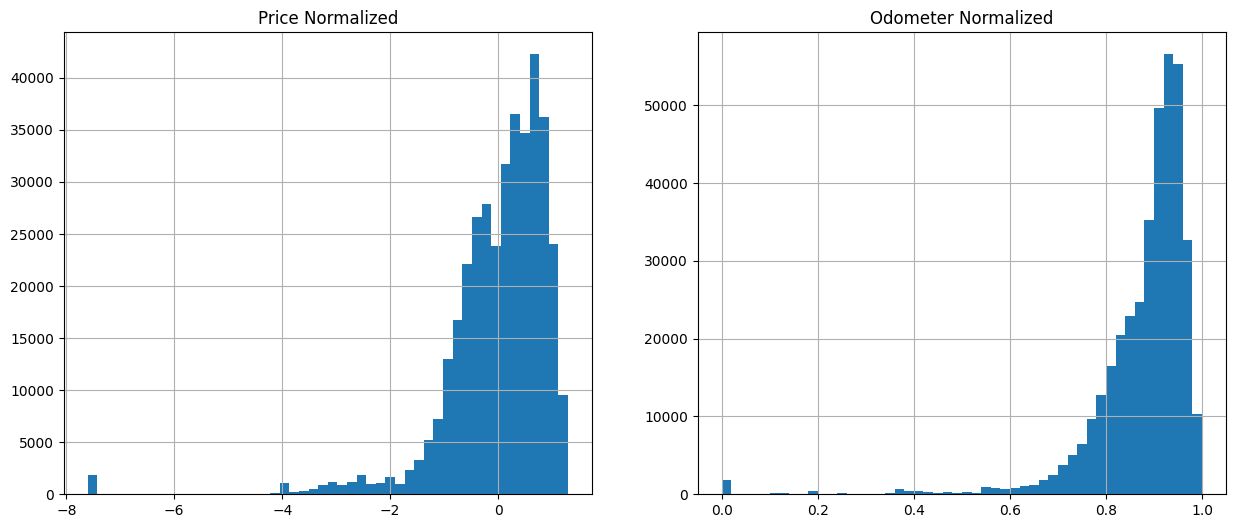

In [206]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
df['price_normalized'].hist(bins=50, ax=ax[0])
ax[0].set_title('Price Normalized')
df['odometer_normalized'].hist(bins=50, ax=ax[1])
ax[1].set_title('Odometer Normalized')
plt.show()

In [207]:
## Feature Creation
# car age from year
df['age'] = df['year'].max() - df['year']

# price per mile metric
df['price_per_mile'] = df['price'] / df['odometer']
# remove outliers from that too
df = remove_outliers_iqr(df, 'price_per_mile')

# after age is created year is redundant
df = df.drop(columns=['year'])

# normalize new values
df['age_normalized'] = minmax.fit_transform(df[['age']])

In [208]:
print(df['price_per_mile'].describe())

count    331751.000000
mean          0.272953
std           0.327004
min           0.000004
25%           0.050000
50%           0.131142
75%           0.367327
max           1.455632
Name: price_per_mile, dtype: float64
